# Calibrated Detection Delay Benchmarks (New API)

This notebook calibrates detector thresholds under the null and compares detection delays for four groups of methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gridcp.detector import GridDetector
from gridcp.calibration import (
    calibrate_detector_threshold_false_alarm,
    mc_alarm_times,
    with_calibrated_threshold,
)
from gridcp.scores import (
    MeanCUSUM,
    MeanCUSUMUnknownVariance,
    MeanOrVariance,
    Variance,
    MultivariateMeanIdentityCov,
    MultivariateMeanUnknownCov,
    MultivariateMeanOrCovariance,
    RegressionMcScan,
    RegressionDirect,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Global Monte Carlo settings
FALSE_ALARM_PROBABILITY = 0.05
N_PATHS_CALIBRATE = 1000
N_PATHS_EVAL = 1000
N_JOBS = 18


def scalar_normal_sampler(rng, loc=0.0, scale=1.0):
    return rng.normal(loc=loc, scale=scale)


def vector_normal_sampler(rng, mean, scale=1.0):
    return rng.normal(loc=mean, scale=scale)


def regression_sampler(rng, beta, sigma=1.0):
    x = rng.normal(loc=0.0, scale=1.0, size=beta.shape[0])
    y = float(x @ beta + rng.normal(loc=0.0, scale=sigma))
    return np.concatenate(([y], x))


def calibrate_detectors(detectors, stream_len, pre_sampler, pre_kwargs, seed):
    calibrated = {}
    for i, (name, det) in enumerate(detectors.items()):
        threshold = calibrate_detector_threshold_false_alarm(
            detector=det,
            false_alarm_probability=FALSE_ALARM_PROBABILITY,
            n_paths=N_PATHS_CALIBRATE,
            stream_len=stream_len,
            pre_sampler=pre_sampler,
            pre_kwargs=pre_kwargs,
            rng=seed + i,
            parallel=True,
            n_jobs=N_JOBS,
        )
        calibrated[name] = with_calibrated_threshold(det, threshold)
    return calibrated


def delay_summary(alarm_times, changepoint, stream_len):
    delays = alarm_times - changepoint
    delays = delays[delays >= 0]  # Only consider alarms after the changepoint
    return {
        "mean_delay": float(np.mean(delays)),
        "median_delay": float(np.median(delays)),
        "alarm_rate": float(np.mean(alarm_times < stream_len)),
    }


def evaluate_delay_curve(
    detectors,
    stream_len,
    changepoint,
    pre_sampler,
    pre_kwargs,
    post_sampler,
    post_kwargs_builder,
    signal_values,
    seed,
):
    rows = []
    for signal in signal_values:
        post_kwargs = post_kwargs_builder(signal)
        for j, (name, det) in enumerate(detectors.items()):
            alarm_times = mc_alarm_times(
                detector=det,
                n_paths=N_PATHS_EVAL,
                stream_len=stream_len,
                pre_sampler=pre_sampler,
                pre_kwargs=pre_kwargs,
                post_sampler=post_sampler,
                post_kwargs=post_kwargs,
                changepoint=changepoint,
                rng=seed + j,
                parallel=True,
                n_jobs=N_JOBS,
            )
            stats = delay_summary(alarm_times, changepoint, stream_len)
            rows.append(
                {
                    "signal": float(signal),
                    "detector": name,
                    **stats,
                }
            )
    return pd.DataFrame(rows)


def plot_delay_curve(df, x_label, title):
    plt.figure(figsize=(8, 4))
    for name, grp in df.groupby("detector"):
        grp = grp.sort_values("signal")
        plt.plot(grp["signal"], grp["mean_delay"], marker="o", label=name)
    plt.xlabel(x_label)
    plt.ylabel("Mean detection delay (indices)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1) Mean-change setting: calibrate known/unknown variance mean detectors + mean-or-variance

In [3]:
stream_len_1 = 180
changepoint_1 = stream_len_1 // 2

mean_detectors_raw = {
    "MeanCUSUM (known variance)": GridDetector(MeanCUSUM(n_features=1), threshold=1.0),
    "MeanCUSUMUnknownVariance": GridDetector(
        MeanCUSUMUnknownVariance(n_features=1), threshold=1.0
    ),
    "MeanOrVariance": GridDetector(MeanOrVariance(n_features=1), threshold=1.0),
}

mean_detectors = calibrate_detectors(
    detectors=mean_detectors_raw,
    stream_len=stream_len_1,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    seed=1100,
)

mean_signal_grid = np.linspace(0.0, 1.4, num=8)
mean_delay_df = evaluate_delay_curve(
    detectors=mean_detectors,
    stream_len=stream_len_1,
    changepoint=changepoint_1,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    post_sampler=scalar_normal_sampler,
    post_kwargs_builder=lambda mu: {"loc": float(mu), "scale": 1.0},
    signal_values=mean_signal_grid,
    seed=1200,
)

pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
mean_delay_df.sort_values(["detector", "signal"]).head(20)

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.000,MeanCUSUM (known variance),89.889,90.000,0.054
3,0.200,MeanCUSUM (known variance),89.818,90.000,0.056
6,0.400,MeanCUSUM (known variance),88.480,90.000,0.101
9,0.600,MeanCUSUM (known variance),79.696,90.000,0.309
12,0.800,MeanCUSUM (known variance),56.381,55.000,0.716
15,1.000,MeanCUSUM (known variance),31.864,25.000,0.957
18,1.200,MeanCUSUM (known variance),18.061,16.000,1.000
21,1.400,MeanCUSUM (known variance),12.672,12.000,1.000
1,0.000,MeanCUSUMUnknownVariance,89.937,90.000,0.032
4,0.200,MeanCUSUMUnknownVariance,89.732,90.000,0.038


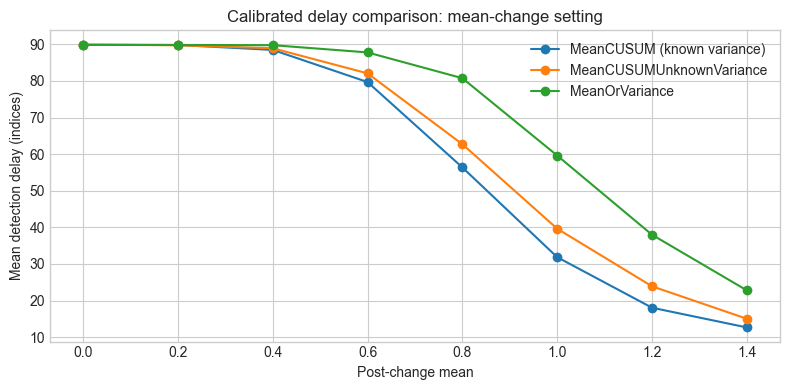

In [4]:
plot_delay_curve(
    mean_delay_df,
    x_label="Post-change mean",
    title="Calibrated delay comparison: mean-change setting",
)

## 2) Variance-change setting: calibrate variance detector + compare to calibrated mean-or-variance detector

In [5]:
stream_len_2 = stream_len_1
changepoint_2 = stream_len_2 // 2

variance_detector = calibrate_detectors(
    detectors={"Variance": GridDetector(Variance(n_features=1), threshold=1.0)},
    stream_len=stream_len_2,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    seed=2100,
)["Variance"]

variance_comparison_detectors = {
    "Variance": variance_detector,
    "MeanOrVariance (from section 1)": mean_detectors["MeanOrVariance"],
}

post_sigmas = np.array([1.0, 1.25, 1.5, 1.75, 2.0])
variance_delay_df = evaluate_delay_curve(
    detectors=variance_comparison_detectors,
    stream_len=stream_len_2,
    changepoint=changepoint_2,
    pre_sampler=scalar_normal_sampler,
    pre_kwargs={"loc": 0.0, "scale": 1.0},
    post_sampler=scalar_normal_sampler,
    post_kwargs_builder=lambda sigma: {"loc": 0.0, "scale": float(sigma)},
    signal_values=post_sigmas,
    seed=2200,
)

variance_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
1,1.000,MeanOrVariance (from section 1),90.000,90.000,0.067
3,1.250,MeanOrVariance (from section 1),89.913,90.000,0.070
5,1.500,MeanOrVariance (from section 1),86.962,90.000,0.123
7,1.750,MeanOrVariance (from section 1),71.882,90.000,0.371
9,2.000,MeanOrVariance (from section 1),45.274,35.500,0.758
0,1.000,Variance,90.000,90.000,0.054
2,1.250,Variance,89.667,90.000,0.062
4,1.500,Variance,84.523,90.000,0.166
6,1.750,Variance,66.220,90.000,0.481
8,2.000,Variance,40.024,28.000,0.826


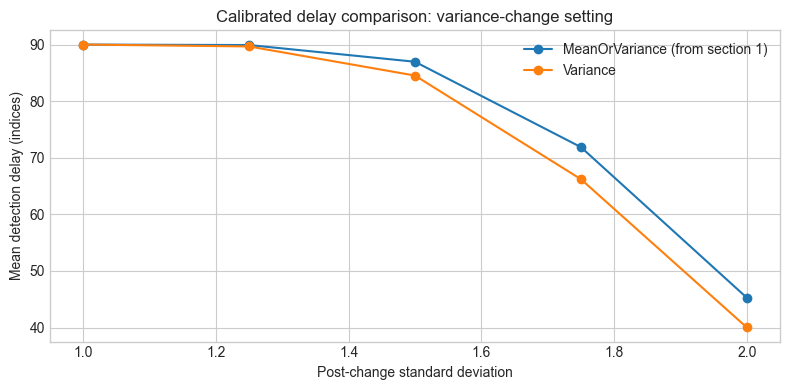

In [6]:
plot_delay_curve(
    variance_delay_df,
    x_label="Post-change standard deviation",
    title="Calibrated delay comparison: variance-change setting",
)

## 3) Multivariate unknown-mean setting: calibrate three methods and compare delays (true sparsity = 1)

In [7]:
p = 10
stream_len_3 = 100
changepoint_3 = stream_len_3 // 2

mu0 = np.zeros(p, dtype=np.float64)

multivariate_detectors_raw = {
    "MultivariateMeanIdentityCov": GridDetector(
        MultivariateMeanIdentityCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanUnknownCov": GridDetector(
        MultivariateMeanUnknownCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanOrCovariance": GridDetector(
        MultivariateMeanOrCovariance(n_features=p), threshold=1.0
    ),
}

multivariate_detectors = calibrate_detectors(
    detectors=multivariate_detectors_raw,
    stream_len=stream_len_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    seed=3100,
)

# True sparsity = 1: only first coordinate changes.
multivariate_signal_grid = np.array([0.0, 0.2, 0.35, 0.5, 0.7, 0.9, 1.1])


def sparse_mean_kwargs(delta):
    mu = np.zeros(p, dtype=np.float64)
    mu[0] = float(delta)
    return {"mean": mu, "scale": 1.0}


multivariate_delay_df = evaluate_delay_curve(
    detectors=multivariate_detectors,
    stream_len=stream_len_3,
    changepoint=changepoint_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    post_sampler=vector_normal_sampler,
    post_kwargs_builder=sparse_mean_kwargs,
    signal_values=multivariate_signal_grid,
    seed=3200,
)

multivariate_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.000,MultivariateMeanIdentityCov,49.785,50.000,0.059
3,0.200,MultivariateMeanIdentityCov,49.785,50.000,0.059
6,0.350,MultivariateMeanIdentityCov,49.737,50.000,0.057
9,0.500,MultivariateMeanIdentityCov,49.469,50.000,0.069
12,0.700,MultivariateMeanIdentityCov,48.285,50.000,0.125
15,0.900,MultivariateMeanIdentityCov,42.703,50.000,0.371
18,1.100,MultivariateMeanIdentityCov,33.550,35.000,0.712
2,0.000,MultivariateMeanOrCovariance,48.745,50.000,0.065
5,0.200,MultivariateMeanOrCovariance,48.948,50.000,0.058
8,0.350,MultivariateMeanOrCovariance,48.721,50.000,0.065


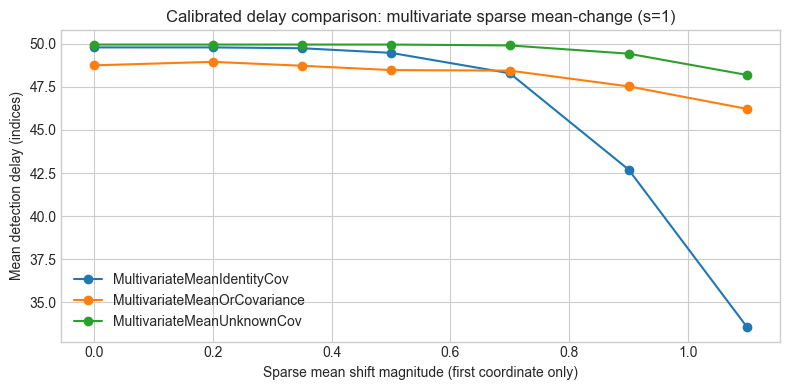

In [8]:
plot_delay_curve(
    multivariate_delay_df,
    x_label="Sparse mean shift magnitude (first coordinate only)",
    title="Calibrated delay comparison: multivariate sparse mean-change (s=1)",
)

## 3.5) Multivariate unknown-mean setting: calibrate three methods and compare delays (true sparsity = p)

In [9]:
p = 10
stream_len_3 = 100
changepoint_3 = stream_len_3 // 2

mu0 = np.zeros(p, dtype=np.float64)

multivariate_detectors_raw = {
    "MultivariateMeanIdentityCov": GridDetector(
        MultivariateMeanIdentityCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanUnknownCov": GridDetector(
        MultivariateMeanUnknownCov(n_features=p), threshold=1.0
    ),
    "MultivariateMeanOrCovariance": GridDetector(
        MultivariateMeanOrCovariance(n_features=p), threshold=1.0
    ),
}

multivariate_detectors = calibrate_detectors(
    detectors=multivariate_detectors_raw,
    stream_len=stream_len_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    seed=3100,
)

# True sparsity = p: all coordinates change.
# multivariate_signal_grid = np.array([0.0, 0.2, 0.35, 0.5, 0.7, 0.9, 1.1])
multivariate_signal_grid = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])


def sparse_mean_kwargs(delta):
    mu = np.ones(p, dtype=np.float64) * delta / np.sqrt(p)
    return {"mean": mu, "scale": 1.0}


multivariate_delay_df = evaluate_delay_curve(
    detectors=multivariate_detectors,
    stream_len=stream_len_3,
    changepoint=changepoint_3,
    pre_sampler=vector_normal_sampler,
    pre_kwargs={"mean": mu0, "scale": 1.0},
    post_sampler=vector_normal_sampler,
    post_kwargs_builder=sparse_mean_kwargs,
    signal_values=multivariate_signal_grid,
    seed=3200,
)

multivariate_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
0,0.000,MultivariateMeanIdentityCov,49.785,50.000,0.059
3,0.500,MultivariateMeanIdentityCov,49.739,50.000,0.060
6,1.000,MultivariateMeanIdentityCov,48.456,50.000,0.129
9,1.500,MultivariateMeanIdentityCov,32.077,31.000,0.784
12,2.000,MultivariateMeanIdentityCov,14.668,14.000,0.998
15,2.500,MultivariateMeanIdentityCov,7.821,7.000,1.000
18,3.000,MultivariateMeanIdentityCov,5.088,5.000,1.000
2,0.000,MultivariateMeanOrCovariance,48.745,50.000,0.065
5,0.500,MultivariateMeanOrCovariance,48.794,50.000,0.068
8,1.000,MultivariateMeanOrCovariance,47.091,50.000,0.140


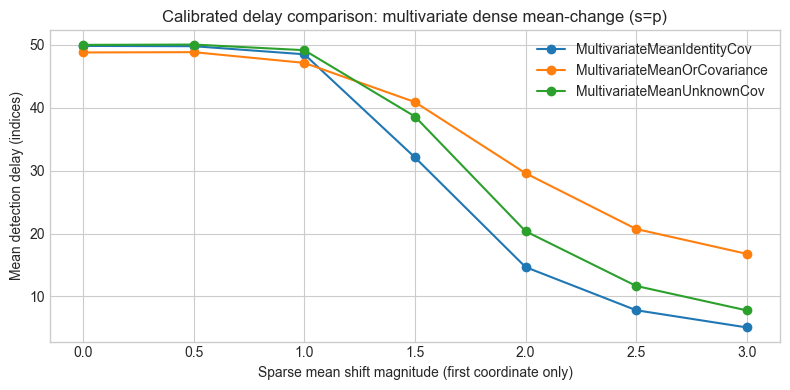

In [10]:
plot_delay_curve(
    multivariate_delay_df,
    x_label="Sparse mean shift magnitude (first coordinate only)",
    title="Calibrated delay comparison: multivariate dense mean-change (s=p)",
)

## 4) Regression-change setting: calibrate McScan and Direct, then compare delays

In [11]:
q = 8
stream_len_4 = 220
changepoint_4 = stream_len_4 // 2

beta0 = np.zeros(q, dtype=np.float64)

regression_detectors_raw = {
    "RegressionMcScan": GridDetector(RegressionMcScan(n_regressors=q), threshold=1.0),
    "RegressionDirect": GridDetector(RegressionDirect(n_regressors=q), threshold=1.0),
}

regression_detectors = calibrate_detectors(
    detectors=regression_detectors_raw,
    stream_len=stream_len_4,
    pre_sampler=regression_sampler,
    pre_kwargs={"beta": beta0, "sigma": 1.0},
    seed=4100,
)

# Regression signal: one-sparse coefficient shift in beta.
regression_signal_grid = np.array([0.0, 0.25, 0.4, 0.55, 0.75, 1.0])


def regression_post_kwargs(delta):
    beta = np.zeros(q, dtype=np.float64)
    beta[0] = float(delta)
    return {"beta": beta, "sigma": 1.0}


regression_delay_df = evaluate_delay_curve(
    detectors=regression_detectors,
    stream_len=stream_len_4,
    changepoint=changepoint_4,
    pre_sampler=regression_sampler,
    pre_kwargs={"beta": beta0, "sigma": 1.0},
    post_sampler=regression_sampler,
    post_kwargs_builder=regression_post_kwargs,
    signal_values=regression_signal_grid,
    seed=4200,
)

regression_delay_df.sort_values(["detector", "signal"])

,signal,detector,mean_delay,median_delay,alarm_rate
1,0.000,RegressionDirect,109.092,110.000,0.071
3,0.250,RegressionDirect,108.822,110.000,0.078
5,0.400,RegressionDirect,105.703,110.000,0.141
7,0.550,RegressionDirect,97.756,110.000,0.329
9,0.750,RegressionDirect,75.884,81.000,0.745
11,1.000,RegressionDirect,46.443,44.000,0.988
0,0.000,RegressionMcScan,108.696,110.000,0.065
2,0.250,RegressionMcScan,108.537,110.000,0.071
4,0.400,RegressionMcScan,106.368,110.000,0.104
6,0.550,RegressionMcScan,103.165,110.000,0.161


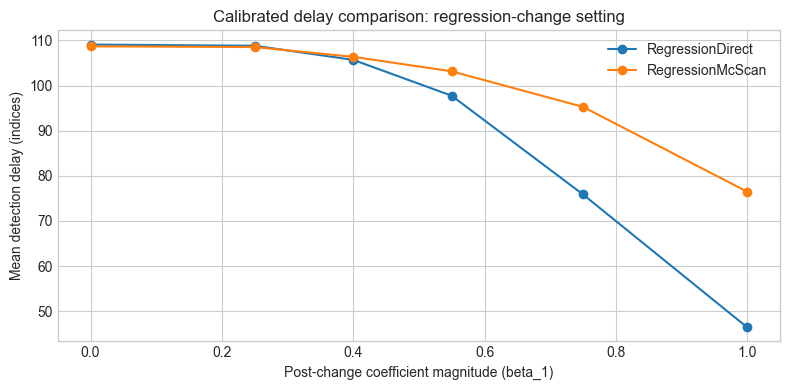

In [12]:
plot_delay_curve(
    regression_delay_df,
    x_label="Post-change coefficient magnitude (beta_1)",
    title="Calibrated delay comparison: regression-change setting",
)

In [ ]:
import numpy as np

rng = np.random.default_rng(123)

rng.standard_normal()

-0.9891213503478509

### 5) Inspect detector state evolution with the calibrated threshold (multivariate identity-covariance mean detector)

In [13]:
identity_threshold = multivariate_detectors["MultivariateMeanIdentityCov"].threshold
print("Calibrated threshold for MultivariateMeanIdentityCov:", identity_threshold)
identity_det = GridDetector(
    MultivariateMeanIdentityCov(n_features=p),
    threshold=1.0,
)

state = identity_det.init_state()
rng = np.random.default_rng(20260328)

print("calibrated threshold:", identity_threshold)
print("initial state:", state)

# Process a short stream: first null observations, then a sparse mean shift on feature 0.
for t in range(8):
    if t < 4:
        x_t = vector_normal_sampler(rng, mean=np.zeros(p), scale=1.0)
    else:
        shifted_mean = np.zeros(p, dtype=np.float64)
        shifted_mean[0] = 0.8
        x_t = vector_normal_sampler(rng, mean=shifted_mean, scale=1.0)

    state, out = identity_det.update(state, x_t)
    print(
        f"t={t + 1:2d} | alarm={out['alarm']} | max_score={out['max_score']} | "
        f"max_score_index={out['max_score_index']}"
    )

print("\nFinal state summary")
print("n_samples:", state.n_samples)
print("grid:", state.grid)
print("num candidate states:", len(state.candidate_score_states))
print("running score state type:", type(state.running_score_state).__name__)
print("running score state:", state.running_score_state)

Calibrated threshold for MultivariateMeanIdentityCov: [3.62406424 3.80728241]
calibrated threshold: [3.62406424 3.80728241]
initial state: DetectorState(running_score_state=MultivariateMeanIdentityCovState(n_samples=0, sum=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])), n_samples=0, candidate_score_states=[], grid=[])
t= 1 | alarm=False | max_score=[0. 0.] | max_score_index=[0 0]
t= 2 | alarm=False | max_score=[ 0.216321 -1.633564] | max_score_index=[0 0]
t= 3 | alarm=True | max_score=[1.08059164 1.56774016] | max_score_index=[0 0]
t= 4 | alarm=True | max_score=[2.21640568 0.51821629] | max_score_index=[1 1]
t= 5 | alarm=True | max_score=[2.13642753 1.47830416] | max_score_index=[1 1]
t= 6 | alarm=True | max_score=[1.93176821 2.40117286] | max_score_index=[0 0]
t= 7 | alarm=True | max_score=[1.95353282 2.35341398] | max_score_index=[0 0]
t= 8 | alarm=True | max_score=[1.84128488 1.86088628] | max_score_index=[0 0]

Final state summary
n_samples: 8
grid: [3, 5, 6, 7]
num candidate sta

## Score runtime benchmark

Approximate per-stream runtime for each score, measured over **N = 1000** observations.  
Multivariate / regression scores use **p = 10** features (or q = 9 regressors + 1 response for regression).


In [14]:
import timeit

N_BENCH = 1000  # stream length
P_BENCH = 10  # features for multivariate / regressors for regression
N_REPEAT = 5  # timeit repeats to take min over
N_RUNS = 3  # timeit number of runs per repeat


def _make_stream(score, n, rng_seed=0):
    """Build a numpy array of observations compatible with *score*."""
    rng = np.random.default_rng(rng_seed)
    n_feat = score.n_features
    return rng.normal(size=(n, n_feat))


def _time_score(score, n=N_BENCH, rng_seed=0):
    """Return minimum wall time (seconds) for one full stream of n observations."""
    x = _make_stream(score, n, rng_seed)
    det = GridDetector(score=score, threshold=1e9)  # threshold never trips

    def run():
        state = det.init_state()
        for xi in x:
            state, _ = det.update(state, xi)

    # Warm up JIT before timing
    run()

    times = timeit.repeat(run, repeat=N_REPEAT, number=N_RUNS)
    return min(times) / N_RUNS  # seconds per stream


# --- define all scores to benchmark ---
bench_scores = {
    "MeanCUSUM (p=1)": MeanCUSUM(n_features=1),
    "MeanCUSUM (p=10)": MeanCUSUM(n_features=P_BENCH),
    "MeanCUSUMUnknownVariance (p=1)": MeanCUSUMUnknownVariance(n_features=1),
    "MeanCUSUMUnknownVariance (p=10)": MeanCUSUMUnknownVariance(n_features=P_BENCH),
    "Variance (p=1)": Variance(n_features=1),
    "Variance (p=10)": Variance(n_features=P_BENCH),
    "MeanOrVariance (p=1)": MeanOrVariance(n_features=1),
    "MeanOrVariance (p=10)": MeanOrVariance(n_features=P_BENCH),
    "MultivariateMeanIdentityCov": MultivariateMeanIdentityCov(n_features=P_BENCH),
    "MultivariateMeanUnknownCov": MultivariateMeanUnknownCov(n_features=P_BENCH),
    "MultivariateMeanOrCovariance": MultivariateMeanOrCovariance(n_features=P_BENCH),
    "RegressionMcScan (q=9)": RegressionMcScan(n_regressors=P_BENCH - 1),
    "RegressionDirect (q=9)": RegressionDirect(n_regressors=P_BENCH - 1),
}

print(f"Benchmarking {len(bench_scores)} scores over N={N_BENCH} observations …")
bench_results = {}
for name, score in bench_scores.items():
    t_sec = _time_score(score)
    bench_results[name] = t_sec
    print(f"  {name:<45s}  {t_sec * 1e3:7.2f} ms")

print("Done.")


Benchmarking 13 scores over N=1000 observations …
  MeanCUSUM (p=1)                                   8.87 ms
  MeanCUSUM (p=10)                                 10.07 ms
  MeanCUSUMUnknownVariance (p=1)                   10.68 ms
  MeanCUSUMUnknownVariance (p=10)                  12.85 ms
  Variance (p=1)                                    7.13 ms
  Variance (p=10)                                   8.56 ms
  MeanOrVariance (p=1)                              8.78 ms
  MeanOrVariance (p=10)                            10.20 ms
  MultivariateMeanIdentityCov                       8.56 ms
  MultivariateMeanUnknownCov                       24.74 ms
  MultivariateMeanOrCovariance                     22.31 ms
  RegressionMcScan (q=9)                            7.28 ms
  RegressionDirect (q=9)                          102.58 ms
Done.


In [15]:
bench_df = pd.DataFrame(
    {
        "Score": list(bench_results.keys()),
        "Time (ms)": [f"{v * 1e3:.2f}" for v in bench_results.values()],
        "Time per obs (µs)": [
            f"{v / N_BENCH * 1e6:.3f}" for v in bench_results.values()
        ],
    }
)
bench_df = bench_df.set_index("Score")
bench_df.index.name = f"Score  (N={N_BENCH}, p={P_BENCH})"
bench_df


,Time (ms),Time per obs (µs)
"Score (N=1000, p=10)",,
MeanCUSUM (p=1),8.87,8.868
MeanCUSUM (p=10),10.07,10.071
MeanCUSUMUnknownVariance (p=1),10.68,10.685
MeanCUSUMUnknownVariance (p=10),12.85,12.846
Variance (p=1),7.13,7.133
Variance (p=10),8.56,8.561
MeanOrVariance (p=1),8.78,8.779
MeanOrVariance (p=10),10.20,10.198
MultivariateMeanIdentityCov,8.56,8.562


### RegressionDirect: is numba active?

`RegressionDirect` was already numba-fied in the same session as the other scores.  
The kernel `regression_direct_score` (and its helper `inv_sqrtm_pd_nb`) both carry `@nb.njit(cache=True)`.  
The cell below verifies this and shows how much of the 99 ms is unavoidable eigendecomposition work vs Python overhead.


In [16]:
import numba as nb
from gridcp.scores._regression_direct import regression_direct_score
from gridcp.scores._score_helpers import inv_sqrtm_pd, inv_sqrtm_pd_nb

# 1. Confirm the kernel is a compiled Numba dispatcher
print("regression_direct_score type :", type(regression_direct_score))
print("inv_sqrtm_pd_nb type         :", type(inv_sqrtm_pd_nb))
print()

# 2. Compare numba vs pure-Python inv_sqrtm_pd on a single matrix
rng2 = np.random.default_rng(0)
M = rng2.normal(size=(9, 9))
X_pd = M.T @ M + np.eye(9)  # guaranteed positive-definite

# warm up
_ = inv_sqrtm_pd_nb(X_pd)

t_py = timeit.timeit(lambda: inv_sqrtm_pd(X_pd), number=10_000) / 10_000
t_nb = timeit.timeit(lambda: inv_sqrtm_pd_nb(X_pd), number=10_000) / 10_000
print(f"inv_sqrtm_pd   (Python/numpy):  {t_py * 1e6:.2f} µs per call")
print(f"inv_sqrtm_pd_nb (numba njit):   {t_nb * 1e6:.2f} µs per call")
print(f"Speed-up: {t_py / t_nb:.1f}×")
print()

# 3. Estimate how many eigh calls happen during a 1000-step stream
#    Grid has O(log t) candidates; total = sum_{t=1}^{N} floor(log2(t))
from gridcp.utils import get_changeloc_grid

total_candidates = sum(len(get_changeloc_grid(t)) for t in range(1, N_BENCH + 1))
print(f"Total grid candidates over N={N_BENCH} steps: {total_candidates:,}")
print(f"That's {2 * total_candidates:,} eigh(9×9) calls (2 per candidate)")
print(
    f"At {t_nb * 1e6:.2f} µs each → lower bound {2 * total_candidates * t_nb * 1e3:.1f} ms"
)
print(f"Measured total: {bench_results['RegressionDirect (q=9)'] * 1e3:.1f} ms")


regression_direct_score type : <class 'numba.core.registry.CPUDispatcher'>
inv_sqrtm_pd_nb type         : <class 'numba.core.registry.CPUDispatcher'>

inv_sqrtm_pd   (Python/numpy):  10.35 µs per call
inv_sqrtm_pd_nb (numba njit):   3.61 µs per call
Speed-up: 2.9×

Total grid candidates over N=1000 steps: 15,447
That's 30,894 eigh(9×9) calls (2 per candidate)
At 3.61 µs each → lower bound 111.6 ms
Measured total: 102.6 ms


### MultivariateMeanUnknownCov and MultivariateMeanOrCovariance: numba-fied

Both scores are now JIT-compiled.  `np.linalg.slogdet` is supported in numba nopython mode (with SciPy installed), so the kernels use it directly — no approximation or workaround needed.

In [17]:
import importlib
import gridcp.scores._multivariate_mean_unknown_cov as _mmuc
import gridcp.scores._multivariate_mean_or_covariance as _mmoc

importlib.reload(_mmuc)
importlib.reload(_mmoc)

from gridcp.scores._multivariate_mean_unknown_cov import (
    multivariate_mean_unknown_cov_score,
)
from gridcp.scores._multivariate_mean_or_covariance import (
    multivariate_mean_or_covariance_score,
)

print(
    "multivariate_mean_unknown_cov_score type   :",
    type(multivariate_mean_unknown_cov_score),
)
print(
    "multivariate_mean_or_covariance_score type :",
    type(multivariate_mean_or_covariance_score),
)
print()
print(
    f"MultivariateMeanUnknownCov   {bench_results['MultivariateMeanUnknownCov'] * 1e3:.2f} ms  (N={N_BENCH}, p={P_BENCH})"
)
print(
    f"MultivariateMeanOrCovariance {bench_results['MultivariateMeanOrCovariance'] * 1e3:.2f} ms  (N={N_BENCH}, p={P_BENCH})"
)


multivariate_mean_unknown_cov_score type   : <class 'numba.core.registry.CPUDispatcher'>
multivariate_mean_or_covariance_score type : <class 'numba.core.registry.CPUDispatcher'>

MultivariateMeanUnknownCov   24.74 ms  (N=1000, p=10)
MultivariateMeanOrCovariance 22.31 ms  (N=1000, p=10)
